In [ ]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tradinglab.data_feed import DataFeed

torch.manual_seed(0)
np.random.seed(0)

# 1. Load one stock
feed = DataFeed.from_dir('data/egx', symbols=['ABUK'])
returns = feed.returns[:, 0]   # daily returns for ABUK

X = returns[:-1].reshape(-1, 1)   # feature: previous day's return
y = returns[1:]                    # target: next day's return

# 3. 70/30 split — train on the PAST, test on the FUTURE (no shuffling!)
split = int(len(X) * 0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# 4. A small MLP
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# 5. Train, tracking both losses each epoch
train_losses, test_losses = [], []
epochs = 200

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    pred_train = model(X_train_t)
    loss_train = loss_fn(pred_train, y_train_t)
    loss_train.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t)
        loss_test = loss_fn(pred_test, y_test_t)

    train_losses.append(loss_train.item())
    test_losses.append(loss_test.item())

print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Final test loss:  {test_losses[-1]:.6f}")

Final train loss: 0.000481
Final test loss:  0.000679


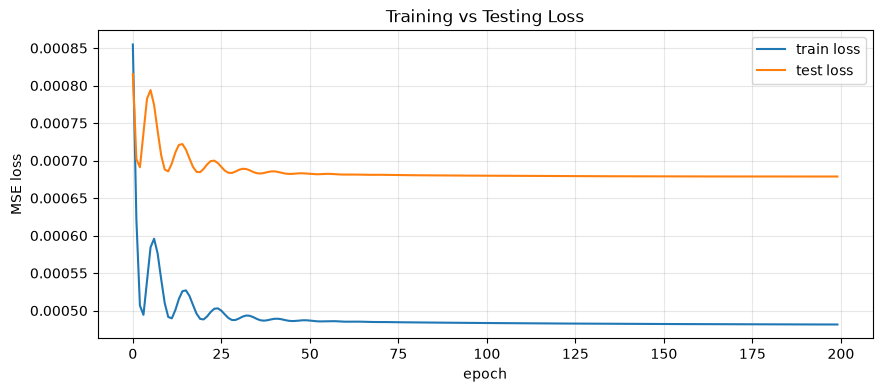

In [2]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Training vs Testing Loss')
plt.show()

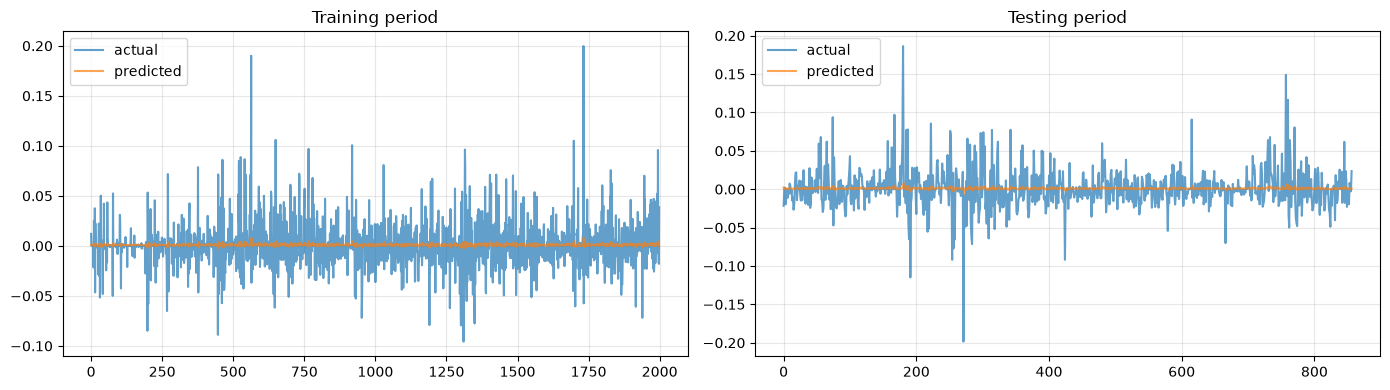

In [3]:
model.eval()
with torch.no_grad():
    pred_train_final = model(X_train_t).squeeze().numpy()
    pred_test_final = model(X_test_t).squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(y_train, label='actual', alpha=0.7)
axes[0].plot(pred_train_final, label='predicted', alpha=0.7)
axes[0].set_title('Training period')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(y_test, label='actual', alpha=0.7)
axes[1].plot(pred_test_final, label='predicted', alpha=0.7)
axes[1].set_title('Testing period')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 6. Accuracy metrics — how good are these predictions, really?

def directional_accuracy(actual, predicted):
    actual_direction = np.sign(actual)
    predicted_direction = np.sign(predicted)
    correct = (actual_direction == predicted_direction).mean()
    return correct

train_dir_acc = directional_accuracy(y_train, pred_train_final)
test_dir_acc = directional_accuracy(y_test, pred_test_final)

print(f"Directional accuracy (train): {train_dir_acc:.2%}")
print(f"Directional accuracy (test):  {test_dir_acc:.2%}")
print(f"(Random guessing would give ~50%)")

# A couple of standard regression metrics too, for completeness
mae_train = np.mean(np.abs(y_train - pred_train_final))
mae_test = np.mean(np.abs(y_test - pred_test_final))

print(f"\nMean Absolute Error (train): {mae_train:.6f}")
print(f"Mean Absolute Error (test):  {mae_test:.6f}")

Directional accuracy (train): 39.72%
Directional accuracy (test):  46.79%
(Random guessing would give ~50%)

Mean Absolute Error (train): 0.013900
Mean Absolute Error (test):  0.017136
